#Coding Challenge

 MNIST Classification Using LeNet-5 (PyTorch Implementation)

**Dataset:** MNIST dataset of handwritten digits

In [9]:
# Import the required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [10]:
# Dataset Preparation
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#Split training data into train and validation
train_set, val_set = random_split(mnist_train, [50000, 10000])
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False)


In [11]:
# Define LeNet-5 Model
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.AvgPool2d(2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16*4*4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.tanh(self.conv1(x)))
        x = self.pool(F.tanh(self.conv2(x)))
        x = x.view(-1, 16*4*4)
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

model = LeNet5()

In [12]:
# Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [13]:
# Training Loop
train_losses, val_losses = [], []
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

Epoch 1, Train Loss: 0.3544, Val Loss: 0.1485
Epoch 2, Train Loss: 0.1123, Val Loss: 0.0937
Epoch 3, Train Loss: 0.0763, Val Loss: 0.0890
Epoch 4, Train Loss: 0.0587, Val Loss: 0.0751
Epoch 5, Train Loss: 0.0481, Val Loss: 0.0634
Epoch 6, Train Loss: 0.0386, Val Loss: 0.0648
Epoch 7, Train Loss: 0.0330, Val Loss: 0.0553
Epoch 8, Train Loss: 0.0287, Val Loss: 0.0666
Epoch 9, Train Loss: 0.0238, Val Loss: 0.0603
Epoch 10, Train Loss: 0.0198, Val Loss: 0.0594


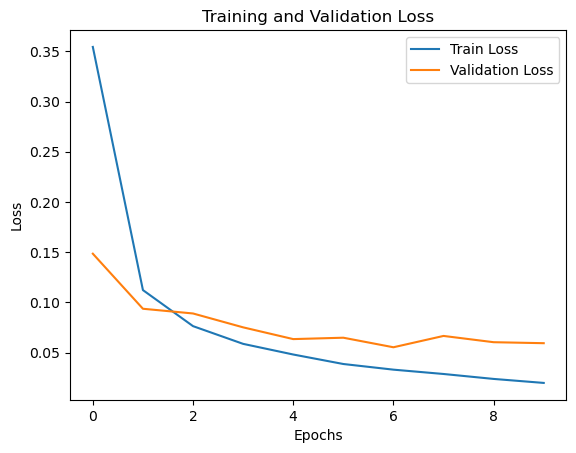

In [14]:
# Visualization of Loss
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [15]:
# Evaluation on Test Set
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       1.00      0.98      0.99      1032
           3       0.96      1.00      0.98      1010
           4       0.99      0.98      0.99       982
           5       0.98      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



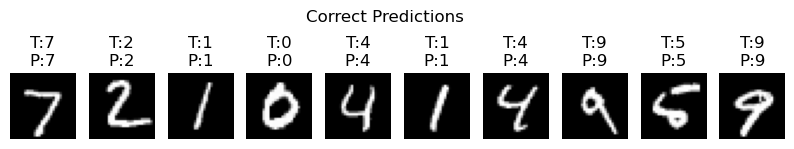

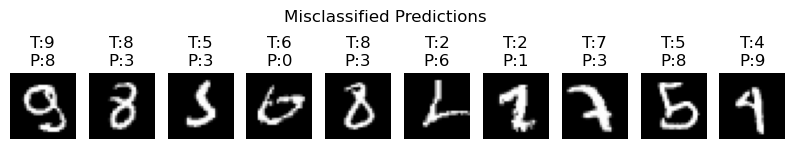

In [16]:
# Visualize Correct and Misclassified Images
correct = [i for i, (a, b) in enumerate(zip(y_true, y_pred)) if a == b]
incorrect = [i for i, (a, b) in enumerate(zip(y_true, y_pred)) if a != b]

def show_images(indices, title):
    plt.figure(figsize=(10, 2))
    for i, idx in enumerate(indices[:10]):
        image = mnist_test[idx][0].squeeze()
        label = y_true[idx]
        pred = y_pred[idx]
        plt.subplot(1, 10, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f"T:{label}\nP:{pred}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(correct, "Correct Predictions")
show_images(incorrect, "Misclassified Predictions")